## Multi-Head Latent Attention

- MLA introduced using of **low-rank matrix factorization** to compress keys and values into a tight latent space, alongside a **Decoupled positional mechanisam** for RoPE.

- MLA instead of storing all K and V for each head stores a latent vector of smaller dim and when attention needs K and V it reconstructs them using learned projection matrices.

### Why MLA?

- In normal MHA(Multi-Head Attention) generating text token-by-token requires storing the KV vectors for all past tokens across all layers and heads to avoid quadractic computations which results in KV cache expanding linearly and starving the GPU of memory and bandwidths as the size of cache grows to be 2xn_headsxd_headsxlayers.

- Memory Scale was O(seq_len x hidden_size) for MHA

- In MQA(Multi-Query Attention) instead of every head having its own K and V, the Keys and Values were shared by all the heads which results in less memory usage but performance drops significantly.

- In GQA(Grouped-Query Attention) instead of 32 sep KV for each head we use 8 shared KV groups which increases memory usage but also performance is not dropped significantly

### How it Works?

- Since K and V are linear transformations of the hidden state, so instead of storing the outputs of those transformations we store a lower-dimensional representation that contains most of the information and then regenerate K and V when needed.

- It's like storing a zip-file of K & V representations so that extra memory is not consumed and then unzipping the representations whenever K and V are required so that information is maintained.

- MLA trades low memory consumption with extra compute of transforming K and V from latent vector using projections and since GPUs are good at projection and spare compute is present.

##### Decoupled RoPE
- RoPE rotates Q and K based on position. If keys are reconstructed later from a compressed latent vector, the positional information has to remain constant.

- DeepSeek decouples the K,Q representations: one part goes through the latent compression and another small part carries the RoPE-related positional information directly.

- This allows for compression without loosing the positional information which results in long-context attention working well.

### Maths

- **c = W_down x**, 
- when attention needs K,we compute **K = W_up^K c**
* Similarly, **V = W_up^V c**
- *x*: full information about the token at that layer
- *W_down*: a learned compressor. It decides which combinations of features are worth keeping in a samller latent vector.
- *c*: The compressed "summary" of the token, it's the latent vector.
- *W_up^K*: Reconstructs the Key representation from the latent vector.
- *W_up^V*: Reconstructs the value representation from the latent vector.

* **Note**: The representations from latent vector to K and V won't match the original full projection exactly, but training encourage them to be good enough so that the attention behaves almost identically while the cache becomes much smaller.

### Tradeoff:- 
- Memory is reduced
- Compute is increased because K and V are reconstructed
- Quality is preserved
### Limitations:- 
- Reconstruction adds extra matrix multiplication during inference.
- Latent dimension design must be balanced: Too-small loses information, too large reduces the memory saved.

## Implementation

In [2]:
import math 
import torch 
import torch.nn as nn 
import torch.nn.functional as F

In [3]:
class RoPE(nn.Module):
    def __init__(self, dim, max_seq_len = 4096):
        super().__init__()
        self.dim = dim 
        
        #Since theta_i = base ^ (-2i/d)
        # i ranges from 0 to d - 2
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim ))
        
        #Declare inv_freq as a buffer meaning it will be bundeled with model but won't be a learnable param
        self.register_buffer("inv_freq", inv_freq, persistent=False)
        
        t = torch.arange(max_seq_len, dtype = torch.float32)
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim = -1)
        self.register_buffer("cos_cached", emb.cos(), persistent = False)
        self.register_buffer("sin_cached", emb.sin(), persistent = False)
        
    def _rotate_half(self, x):
        x1 = x[..., :self.dim // 2]
        x2 = x[..., self.dim//2:]
        
        return torch.cat((-x2, x1), dim = -1)
    
    def forward(self, x, seq_len):
        #x shape: [batch_dim, num_head, num_layer, dimension_R]
        cos = self.cos_cached[:seq_len, :].unsqueeze(0).unsqueeze(1) #[1,1, num_layer, d_R]
        sin = self.sin_cached[:seq_len, :].unsqueeze(0).unsqueeze(1) #[1,1, num_layer, d_R]
        
        return (x * cos) + (self._rotate_half(x) * sin)    

In [8]:
class MultiHeadLatentAttention(nn.Module):
    def __init__(self, d_model, n_head, d_head, d_R, r, r_Q):
        super().__init__()
        
        self.num_head = n_head
        self.dim_head = d_head
        self.dim_R = d_R
        self.r = r
        self.r_Q = r_Q
        self.scale = 1.0 / math.sqrt(d_head +  d_R)
        
        #======Query Projection(Low-rank compression + Decompression)========
        self.W_DownQ = nn.Linear(d_model, r_Q, bias = False)
        #DeepSeek uses layer-Normalization inside the compression
        self.ln_q =  nn.LayerNorm(r_Q)  
        self.W_UpQ = nn.Linear(r_Q, n_head * d_head, bias = False)
        #Query RoPE component
        self.W_QR = nn.Linear(r_Q, n_head * d_R, bias = False) 
        
        #======Key-Value Compression Path==========
        self.W_DownKV = nn.Linear(d_model, r, bias = False)
        self.ln_kv = nn.LayerNorm(r)
        
        #======Key-Value Decompression Path=========
        self.W_UpK = nn.Linear(r, n_head * d_head, bias = False)
        self.W_UpV = nn.Linear(r, n_head * d_head, bias = False)
        #Key RoPE component
        self.W_KR = nn.Linear(r, d_R, bias = False)
        
        #======Output Projection=========
        self.W_O = nn.Linear(n_head * d_head, d_model, bias = False)
        
        #RoPE handler
        self.rope = RoPE(dim = d_R)
        
    def forward(self, x, kv_cache = None):
        #Get the dimensions
        B, N, _ = x.shape
        
        #==========Generate Compressed Queries=============
        down_x = self.W_DownQ(x)
        c_Q = self.ln_q(down_x) 
        
        #DECOUPLE into latent info queries and positional info queries
        q_latent = self.W_UpQ(c_Q).view(B, N, self.num_head, self.dim_head).transpose(1, 2) #[B, num_head, N, dim_head]
        q_rope = self.W_QR(c_Q).view(B, N, self.num_head, self.dim_R).transpose(1,2) #[B, num_head, N, dim_R]
        
        
        #==========Generate Compressed Keys/Values=========
        down_kv = self.W_DownKV(x)
        c_KV = self.ln_kv(down_kv)
        
        #we only cache c_kv and the shared k_rope
        k_rope = self.W_KR(c_KV).view(B, N, 1, self.dim_R).transpose(1, 2) #[B, 1, N, d_R]
        k_rope = k_rope.expand(-1, self.num_head, -1, -1)                  #[B, n_head, N, d_R]
        
        
        #Check for KV_Cache if already present then update it
        if kv_cache is not None: 
            c_kv_prev, k_rope_prev = kv_cache
            #Update the KV_Cache
            c_KV = torch.cat([c_kv_prev, c_KV], dim = 1)
            k_rope = torch.cat([k_rope_prev, k_rope], dim = 2)
            
        new_kv_cache = (c_KV, k_rope)
        total_N_kv = c_KV.shape[1]
        
        #Decompress into full multi-head K and V from the cached latent representation
        k_latent = self.W_UpK(c_KV).view(B, total_N_kv, self.num_head, self.dim_head).transpose(1, 2)  #[B, n_head, N_Kv, d_head]
        v_latent = self.W_UpV(c_KV).view(B, total_N_kv, self.num_head, self.dim_head).transpose(1, 2)  #[B, n_head, N_Kv, d_head]
        
        #===========Apply DECOUPLED RoPE===============
        q_rope = self.rope(q_rope, seq_len = N)
        k_rope = self.rope(k_rope, seq_len = total_N_kv)
        
        #============Concatenate Latent and Position vectors============
        Q = torch.cat([q_latent, q_rope], dim = -1)     #[B, n_head, N, d_head + d_R]
        K = torch.cat([k_latent, k_rope], dim = -1)     #[B, n_head, N, d_head + d_R]
        
        #============ATTENTION IS ALL IT NEEDSS=================
        
         #{Notice how scale contains sum of d_head, d_R}
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale      #[B, n_head, N, N_kv]
        
        #Add Causal Mask if generating 
        if N > 1:
            mask = torch.full((N, total_N_kv), float("-inf"), device = x.device).triu(1)
            scores = scores + mask 
            
        attn_weights = F.softmax(scores, dim = -1)
        
        #Multiply attn matrix with latent_V
        context = torch.matmul(attn_weights, v_latent)      #[B, n_head, N, d_head]
        
        context  = context.transpose(1,2).contiguous().view(B, N, self.num_head * self.dim_head)
        
        output = self.W_O(context)
        
        return output, new_kv_cache
        
        
            

### Visualization Code

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns 

In [9]:
def run_visualization():
    B = 1 #Batch Size
    N = 12 #Sequence Length
    d_model = 64  #Embedding Dimension
    n_h = 4     #number of heads
    d_h = 16    #Latent head dimension
    d_R = 8     #RoPE head dimension
    r = 32      #KV compression rank
    r_Q = 32    #Query compression Rank
    
    mla = MultiHeadLatentAttention(d_model, n_h, d_h, d_R, r, r_Q)
    mla.eval()
    
    #dummy token
    x = torch.randn(B, N, d_model)   #[batch, seq_len, hidden_dim]
    
    with torch.no_grad():
        c_Q = mla.ln_q(mla.W_DownQ(x))
        q_latent = mla.W_UpQ(c_Q).view(B, N, n_h, d_h).transpose(1, 2)
        q_rope = mla.W_QR(c_Q).view(B, N, n_h, d_R).transpose(1, 2)
        q_rope = mla.rope(q_rope, seq_len = N)
        Q = torch.cat([q_latent, q_rope], dim = -1)
        
        c_KV = mla.ln_kv(mla.W_DownKV(x))
        k_rope = mla.W_KR(c_KV).view(B, N, 1, d_R).transpose(1, 2).expand(-1, n_h, -1, -1)
        k_rope = mla.rope(k_rope, seq_len = N)
        k_latent = mla.W_UpK(c_KV).view(B, N, n_h, d_h).transpose(1, 2)
        v_latent = mla.W_UpV(c_KV).view(B, N, n_h, d_h).transpose(1, 2)
        K = torch.cat([k_latent, k_rope], dim = -1)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) * mla.scale
        mask = torch.full((N, N), float("-inf"), device = x.device).triu(1)
        scores = scores + mask 
        attn_weights = torch.softmax(scores, dim = -1).squeeze(0)
        
    fig, axes = plt.subplots(2, 2, figsize = (14, 10))
    fig.suptitle("Multi-Head Latent Attention(MLA)", fontsize = 16, fontweight = 'bold')
    
    for idx in range(2):
        ax = axes[0, idx]
        sns.heatmap(attn_weights[idx].numpy(), annot=False, cmap="viridis", cbar=True, ax = ax, 
                    xticklabels = [f"T_{i}" for i in range(N)], yticklabels = [f"T_{i}" for i in range(N)])
        
        ax.set_title(f"Attention Matrix (Head {idx})")
        ax.set_xlabel("Key Tokens (Context)")
        ax.set_ylabel("Query Tokens (Current)")
        
    
    ax_kv = axes[1, 0]
    sns.heatmap(c_KV.squeeze(0).numpy(), cmap = "coolwarm", ax = ax_kv)
    ax_kv.set_title("Compressed KV Cache State ($c^{{KV}}$ Vector Space)")
    ax_kv.set_xlabel("Compressed Latent Dimension($r=32$)")
    ax_kv.set_ylabel("Tokens in Sequence ($N=12$)")
    
    ax_v = axes[1, 1]
    v_head0 = v_latent.squeeze(0)[0]
    sns.heatmap(v_head0.numpy(), cmap = "magma", ax = ax_v)
    ax_v.set_title("Decompressed Projection Matrix ($V_{latent}$ Head 0)")
    ax_v.set_xlabel("Decompreesed Head Dimension ($d_h = 16$)")
    ax_v.set_ylabel("Tokens in Sequence ($N = 12$)")
    
    plt.tight_layout()
    plt.show()
         

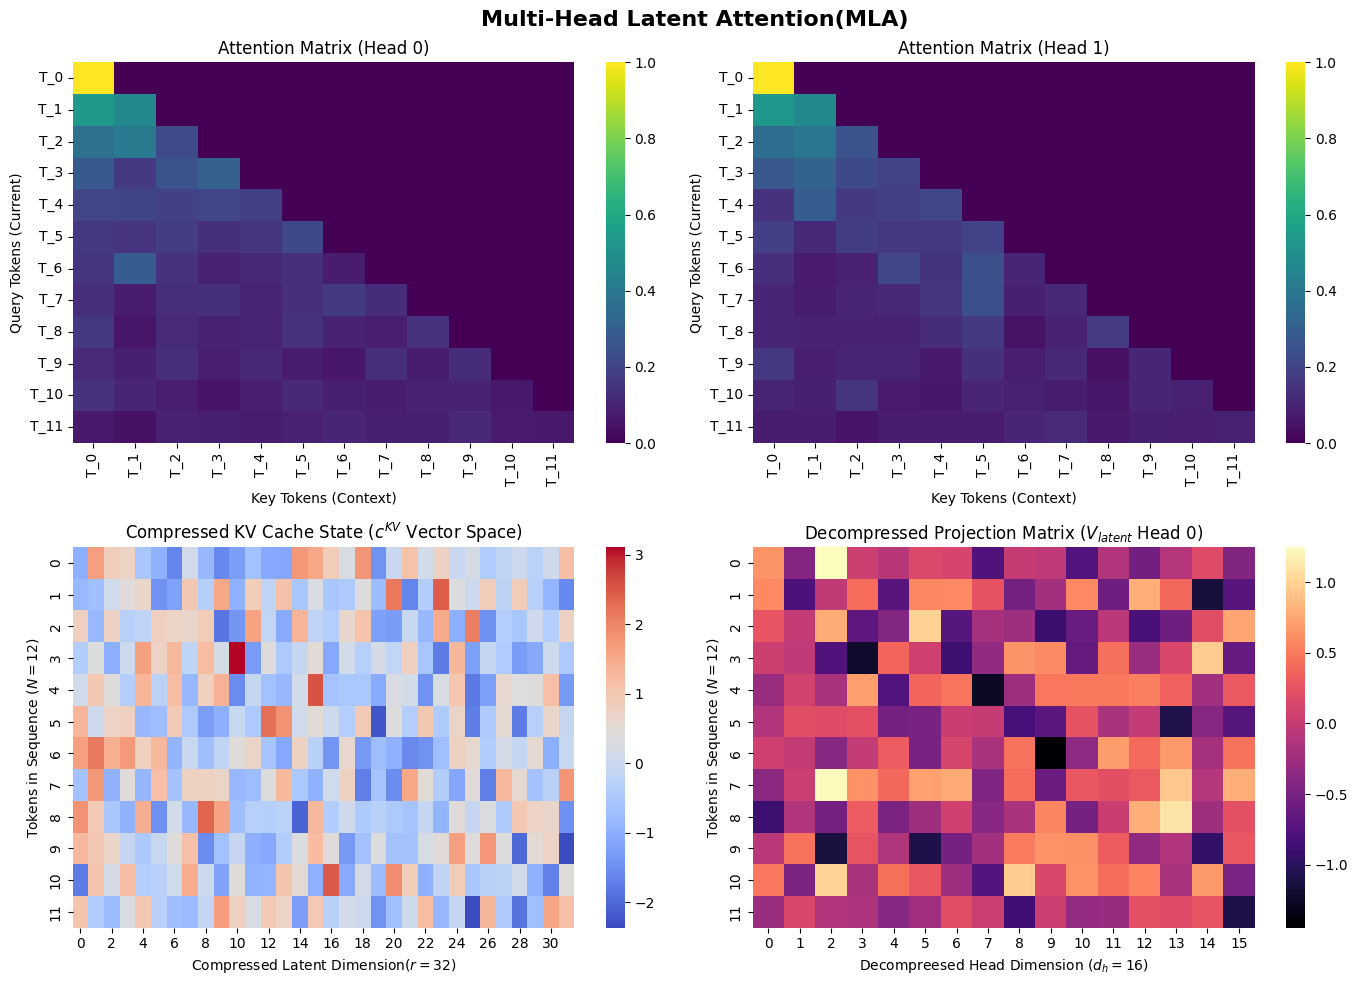

In [10]:
run_visualization()